# round 3, gloves off: fair value estimation under uncertainty

a research notebook on inferring, not declaring, fair value for every product in round 3.

## the pipe on the desk

the image bundled with this round's data is rené magritte's *la trahison des images* (1929). the painting shows a photorealistic pipe above a caption that reads *ceci n'est pas une pipe*, "this is not a pipe".

the point is epistemological. the painting is not the pipe. the caption is not an instruction. what we see is a representation, and a representation is never identical to the thing it represents.

for a quant trader in prosperity, that is the whole sermon:

- the mid price is not the fair value.
- the order book snapshot is not the market.
- the backtest is not the live run.
- a point estimate of fair value is a picture of fair value, never fair value itself.

every model we fit in this notebook is a map. none of them is the territory. the job is to measure how wrong each map is, where it is wrong, and when it stops being useful. confidence must always be stated alongside the number.

the three guiding principles from timo diehm are folded in throughout:

1. question every assumption, especially the ones that feel natural (mid equals fair value, options price off the underlying, spread is a cost).
2. understand the data-generating process at a deeper level than the headline statistics suggest.
3. go the extra mile: test robustness with grid search, walk-forward, combinatorial cross-validation, and stable-plateau selection, not with a single backtested peak.

the deliverable is a per-product recommendation with an explicit confidence level, the empirical evidence, the academic backing, the parameter search landscape, and a clear statement of what would falsify the choice.


## section 0: setup and data loading

three days of data are available:

- `prices_round_3_day_{0,1,2}.csv`: top-of-book plus two deeper levels, sampled every 100 ms (10,000 ticks per day).
- `trades_round_3_day_{0,1,2}.csv`: recorded counterparty trades, with trader ids anonymised in this dataset.

the tte (time to expiry) schedule for the vouchers:
- historical day 0: tte = 8 days (tutorial)
- historical day 1: tte = 7 days (round 1)
- historical day 2: tte = 6 days (round 2)
- live round 3 run: tte = 5 days


In [1]:
# reproducibility and plotting style matched to the frankfurt dashboard spirit.
# scatter orderbook, small glyphs, blue for bids, red for asks, mid as a soft line.
import os, json, math, itertools, warnings
from dataclasses import dataclass
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

warnings.filterwarnings("ignore")
np.random.seed(0)

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

DATA_DIR = "/mnt/project"
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f"VEV_{k}" for k in STRIKES]
ALL_PRODUCTS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"] + VOUCHERS
TICKS_PER_DAY = 10_000
TTE_DAYS_START = {0: 8, 1: 7, 2: 6}  # days to expiry at timestamp 0 on each historical day
LIVE_TTE_DAYS = 5


In [2]:
def load_prices():
    frames = []
    for d in (0, 1, 2):
        df = pd.read_csv(f"{DATA_DIR}/prices_round_3_day_{d}.csv", sep=";")
        df["day"] = d
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out = out.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)
    return out

def load_trades():
    frames = []
    for d in (0, 1, 2):
        df = pd.read_csv(f"{DATA_DIR}/trades_round_3_day_{d}.csv", sep=";")
        df["day"] = d
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

prices_raw = load_prices()
trades_raw = load_trades()

print("prices rows per product per day (sanity check):")
print(prices_raw.groupby(["product", "day"]).size().unstack(fill_value=0))
print()
print("trades counts by product across all 3 days:")
print(trades_raw["symbol"].value_counts())


prices rows per product per day (sanity check):
day                      0      1      2
product                                 
HYDROGEL_PACK        10000  10000  10000
VELVETFRUIT_EXTRACT  10000  10000  10000
VEV_4000             10000  10000  10000
VEV_4500             10000  10000  10000
VEV_5000             10000  10000  10000
VEV_5100             10000  10000  10000
VEV_5200             10000  10000  10000
VEV_5300             10000  10000  10000
VEV_5400             10000  10000  10000
VEV_5500             10000  10000  10000
VEV_6000             10000  10000  10000
VEV_6500             10000  10000  10000

trades counts by product across all 3 days:
symbol
VELVETFRUIT_EXTRACT    1372
HYDROGEL_PACK          1010
VEV_4000                464
VEV_6000                284
VEV_6500                284
VEV_5500                267
VEV_5400                225
VEV_5300                121
VEV_5200                 18
VEV_4500                  1
VEV_5000                  1
VEV_5100          

## section 1: state variables and book-level derived fields

what state variables are actually available per tick?

- top three bid levels with prices and volumes.
- top three ask levels with prices and volumes.
- the exchange-reported `mid_price`, which is just (best_bid + best_ask) / 2.
- `profit_and_loss` is the mark-to-market of some benchmark strategy and can be ignored.

from these we construct six candidate single-number summaries of the book per tick. each is a different representation of the truth. none is the truth.

| field | formula | intuition |
| --- | --- | --- |
| raw mid | (best_bid + best_ask) / 2 | what the exchange ships. bounces with the tightest quoter. |
| wall mid | (outermost_bid + outermost_ask) / 2 | frankfurt's device: averages the deepest layer, which is usually the market maker anchored on the true price. |
| microprice | (best_bid * best_ask_vol + best_ask * best_bid_vol) / (best_bid_vol + best_ask_vol) | imbalance-weighted; nudged toward the thicker side. used widely in microstructure literature (stoikov 2018). |
| vwap level 1 | sum(price * vol) across best bid and ask / total vol | similar to microprice but using same-side weighting. |
| l2 mid | (l2_bid + l2_ask) / 2 when both present, else nan | pure wall, without l1 price-improver. |
| mid ema | ewm of raw mid with span n | temporal smoothing, used for slow signals. |

we also compute spread, total top-of-book volume, and bid/ask volume imbalance for diagnostics.


In [3]:
def enrich_book(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # outer walls: min of any present bid level, max of any present ask level
    bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
    ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
    out["bid_wall"] = out[bid_cols].min(axis=1, skipna=True)
    out["ask_wall"] = out[ask_cols].max(axis=1, skipna=True)
    out["wall_mid"] = (out["bid_wall"] + out["ask_wall"]) / 2.0

    # l2 mid when both l2 sides exist
    l2_both = out["bid_price_2"].notna() & out["ask_price_2"].notna()
    out["l2_mid"] = np.where(l2_both,
                             (out["bid_price_2"] + out["ask_price_2"]) / 2.0,
                             np.nan)

    # microprice
    bp, ap = out["bid_price_1"], out["ask_price_1"]
    bv, av = out["bid_volume_1"], out["ask_volume_1"]
    denom = (bv + av).replace(0, np.nan)
    out["microprice"] = (bp * av + ap * bv) / denom

    # vwap level-1 (symmetric weighting)
    out["vwap_l1"] = (bp * bv + ap * av) / denom

    # book state diagnostics
    out["spread"] = ap - bp
    out["best_mid"] = (ap + bp) / 2.0  # same as mid_price from the csv but safer
    out["imbalance"] = (bv - av) / denom

    # per-group ema of mid: need groupby within product, day
    out["mid_ema_5"]  = out.groupby(["product", "day"])["mid_price"].transform(lambda s: s.ewm(span=5,  adjust=False).mean())
    out["mid_ema_20"] = out.groupby(["product", "day"])["mid_price"].transform(lambda s: s.ewm(span=20, adjust=False).mean())
    out["mid_ema_50"] = out.groupby(["product", "day"])["mid_price"].transform(lambda s: s.ewm(span=50, adjust=False).mean())
    return out

prices = enrich_book(prices_raw)
print("enriched columns:", [c for c in prices.columns if c not in prices_raw.columns])
prices.head(3)


enriched columns: ['bid_wall', 'ask_wall', 'wall_mid', 'l2_mid', 'microprice', 'vwap_l1', 'spread', 'best_mid', 'imbalance', 'mid_ema_5', 'mid_ema_20', 'mid_ema_50']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,wall_mid,l2_mid,microprice,vwap_l1,spread,best_mid,imbalance,mid_ema_5,mid_ema_20,mid_ema_50
0,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,...,10000.0,10000.0,10000.0,10000.0,16,10000.0,0.0,10000.0,10000.000000,10000.000000
1,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,...,10000.5,10000.5,10000.0,10000.0,16,10000.0,0.0,10000.0,10000.000000,10000.000000
2,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,...,10002.5,10002.5,10003.0,10003.0,16,10003.0,0.0,10001.0,10000.285714,10000.117647


## section 2: per-product signature

before choosing an estimator, we need a qualitative portrait of each product. the frankfurt writeup emphasised that structural understanding dominates parameter tuning. we begin with a compact per-product table summarising level, variability, book depth, and spread regime.


In [4]:
def product_signature(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for p, g in df.groupby("product"):
        row = {
            "product": p,
            "n_ticks": len(g),
            "mid_mean": g["mid_price"].mean(),
            "mid_std": g["mid_price"].std(),
            "mid_min": g["mid_price"].min(),
            "mid_max": g["mid_price"].max(),
            "spread_median": g["spread"].median(),
            "spread_mode": g["spread"].mode().iloc[0] if len(g["spread"].mode()) else np.nan,
            "L2_bid_present_%": g["bid_price_2"].notna().mean() * 100,
            "L2_ask_present_%": g["ask_price_2"].notna().mean() * 100,
            "L3_bid_present_%": g["bid_price_3"].notna().mean() * 100,
            "tick_size": float(np.median(np.diff(np.sort(g["mid_price"].unique())))) if g["mid_price"].nunique() > 1 else np.nan,
        }
        rows.append(row)
    tbl = pd.DataFrame(rows).set_index("product")
    # natural ordering
    order = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"] + VOUCHERS
    return tbl.loc[[p for p in order if p in tbl.index]]

sig = product_signature(prices)
sig.round(3)


,n_ticks,mid_mean,mid_std,mid_min,mid_max,spread_median,spread_mode,L2_bid_present_%,L2_ask_present_%,L3_bid_present_%,tick_size
product,,,,,,,,,,,
HYDROGEL_PACK,30000,9990.807,31.935,9891.0,10079.0,16.0,16,100.000,100.000,1.580,0.5
VELVETFRUIT_EXTRACT,30000,5250.098,15.630,5198.0,5300.0,5.0,5,54.370,54.537,2.027,0.5
VEV_4000,30000,1250.110,15.647,1198.0,1300.0,21.0,21,100.000,100.000,0.883,0.5
VEV_4500,30000,750.110,15.640,698.5,799.5,16.0,16,100.000,100.000,0.883,0.5
VEV_5000,30000,255.022,14.376,206.5,300.5,6.0,6,64.563,63.657,0.577,0.5
VEV_5100,30000,166.805,12.743,125.0,205.5,4.0,4,42.790,42.160,0.373,0.5
VEV_5200,30000,95.549,9.664,64.0,122.5,3.0,3,24.297,24.610,0.157,0.5
VEV_5300,30000,46.760,6.228,26.5,65.5,2.0,2,14.623,14.750,0.000,0.5
VEV_5400,30000,15.952,3.429,6.5,27.0,1.0,1,4.767,5.020,0.000,0.5


### reading the signature table

three clusters emerge by inspection.

1. `HYDROGEL_PACK`: mid around 9990, mid std about 32, spread mode 16. l2 present 100 percent of the time. tick size 1. a classic market-making candidate with a large liquid quoted book and deep walls.

2. `VELVETFRUIT_EXTRACT`: mid around 5250, std 15, spread 5. l2 present only about 54 percent of the time. tick size 0.5. narrower book, much less wall structure.

3. the vouchers: their mid values and spreads order themselves monotonically in strike. deep itm vouchers (`VEV_4000`, `VEV_4500`) echo the underlying with an offset, wide spreads, and near-100 percent l2 presence. around-the-money strikes have compressing spreads and diminishing l2 presence. `VEV_6000` and `VEV_6500` are flat at mid 0.5 on a one-tick spread, which is a price floor, not a real quote.


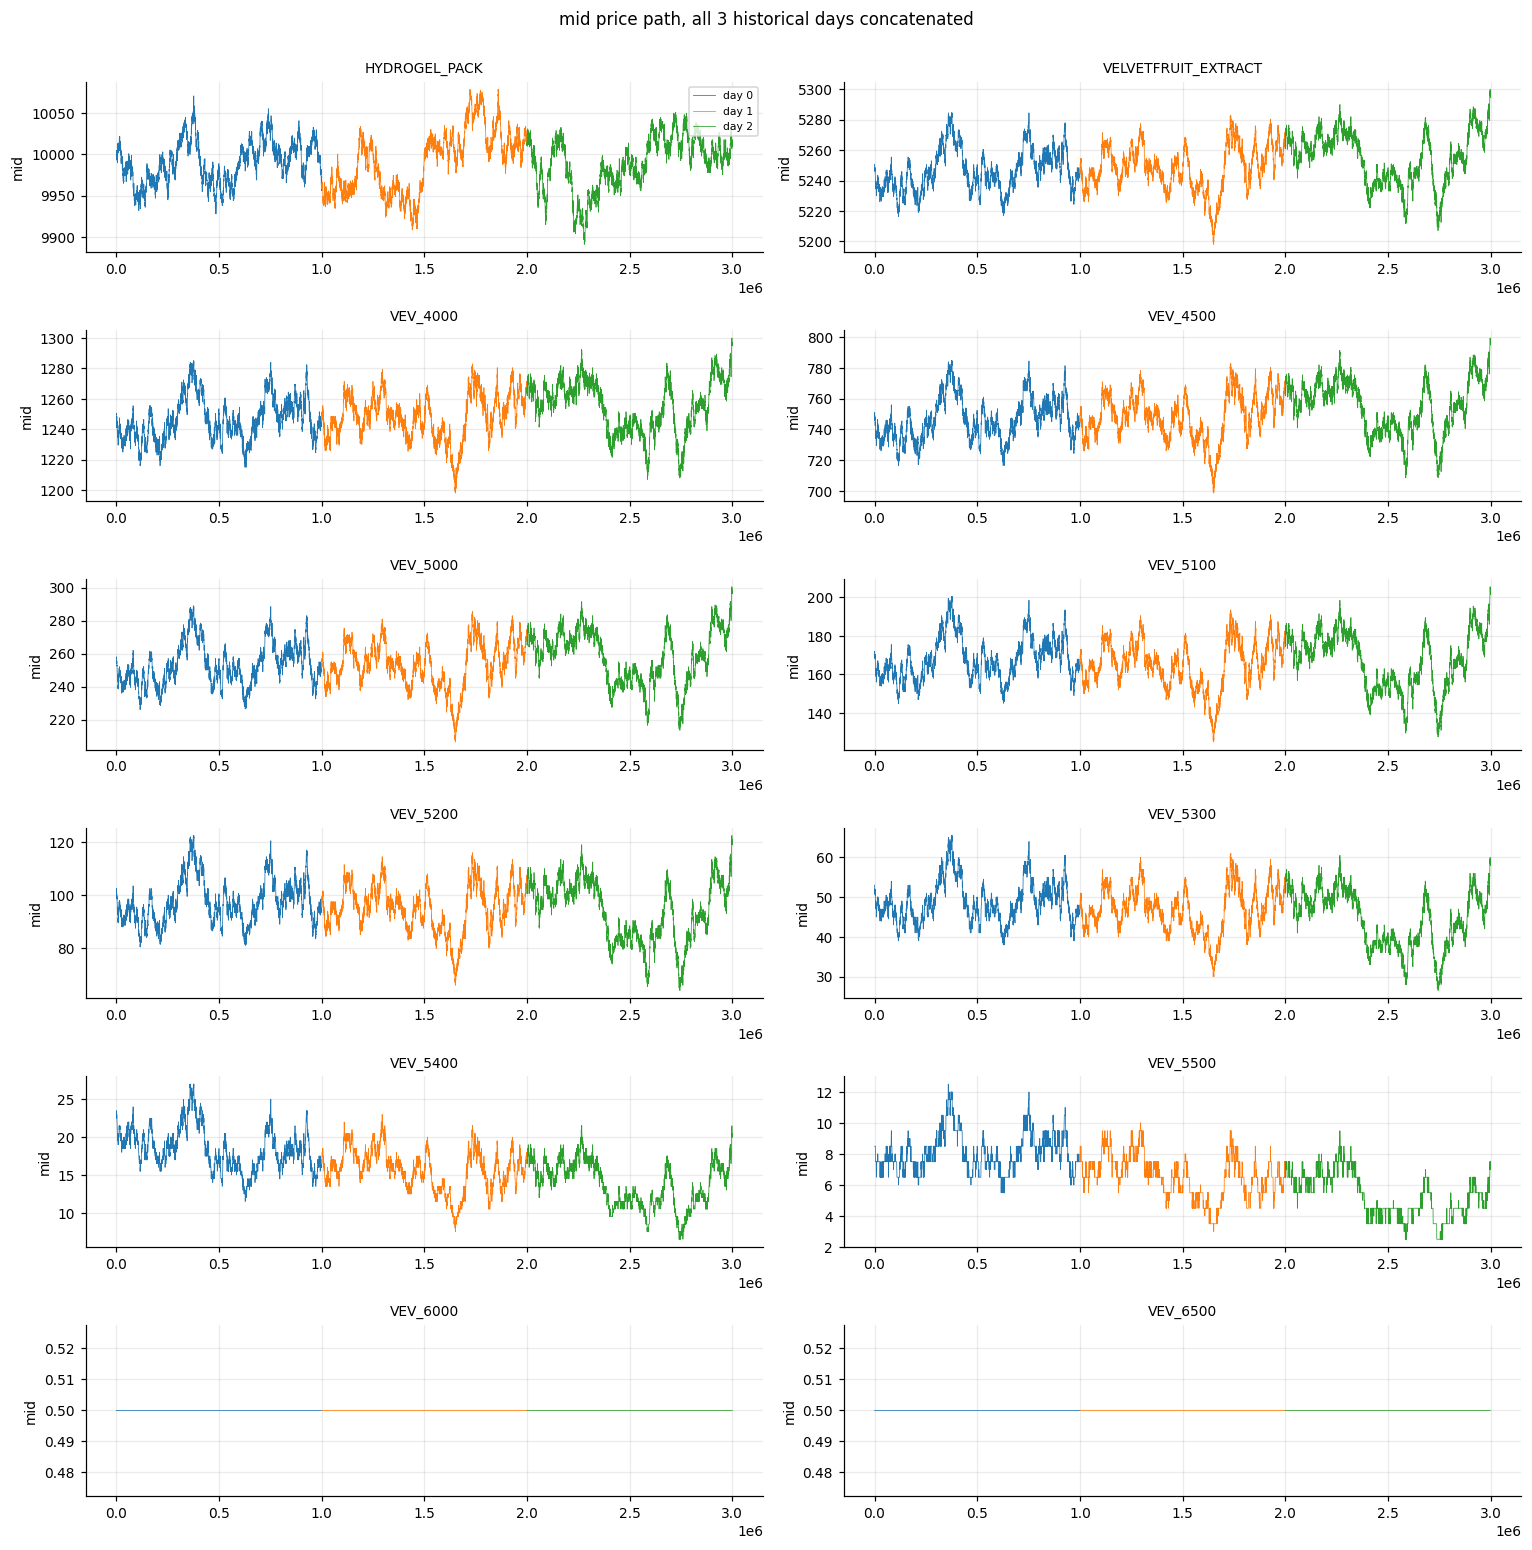

In [5]:
# visual of every product's mid price path across all 3 days concatenated
fig, axes = plt.subplots(6, 2, figsize=(14, 14), sharex=False)
axes = axes.flatten()
for i, p in enumerate(ALL_PRODUCTS):
    ax = axes[i]
    sub = prices[prices["product"] == p]
    for d in (0, 1, 2):
        ss = sub[sub["day"] == d]
        ax.plot(ss["timestamp"].values + d * 1_000_000, ss["mid_price"].values, linewidth=0.5, label=f"day {d}")
    ax.set_title(p, fontsize=9)
    ax.set_ylabel("mid")
    if i == 0:
        ax.legend(fontsize=7, loc="upper right")
fig.suptitle("mid price path, all 3 historical days concatenated", y=1.002, fontsize=11)
plt.tight_layout(); plt.show()


## section 3: frankfurt-style orderbook snapshots

to build intuition the same way the frankfurt team did, we visualise the order book levels as a scatter over time. blue squares are bid levels, red squares are ask levels, size proportional to volume, and the raw mid is overlaid as a translucent line.

the value of this view, beyond aesthetics, is that it makes the "wall" structure obvious when it exists: in products with a deep market-maker book, you see two horizontal blue and red bands at the walls, with a thinner price-improver layer oscillating between them. where the walls are missing, you only see the thin price-improver layer. that distinction determines whether wall mid is a meaningful estimator or merely a restatement of l1 mid.


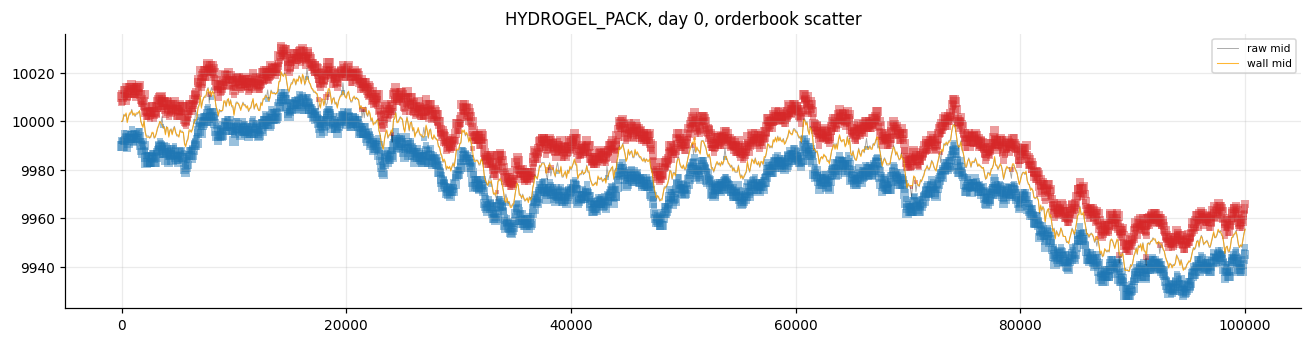

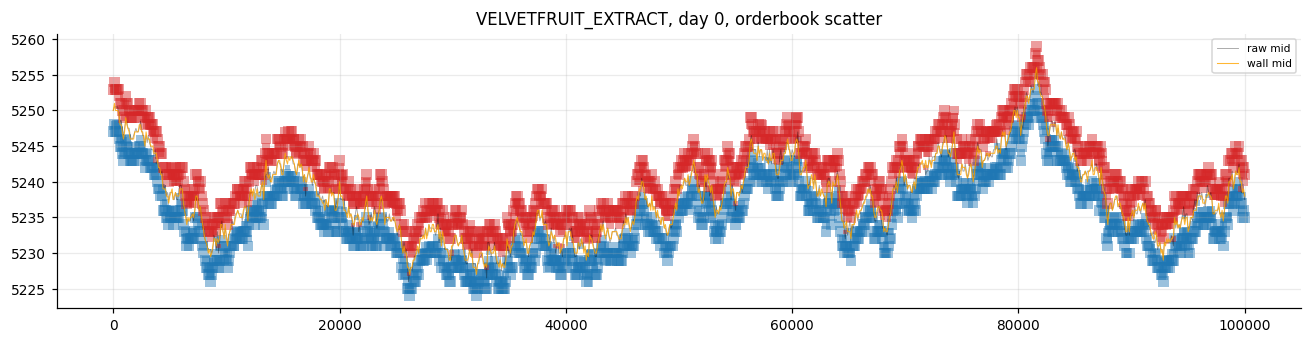

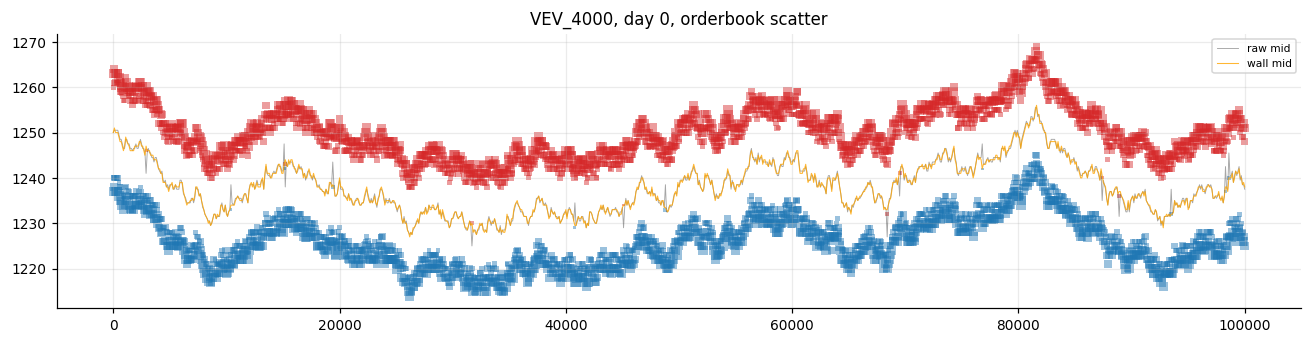

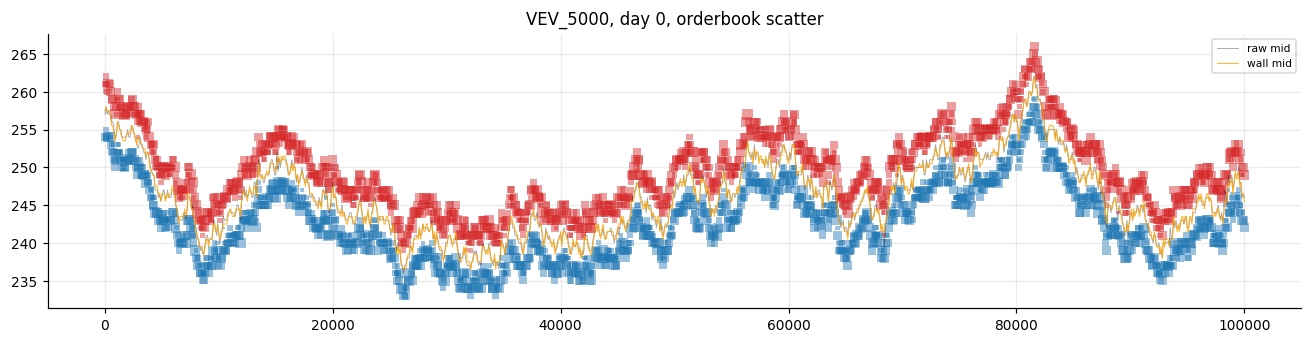

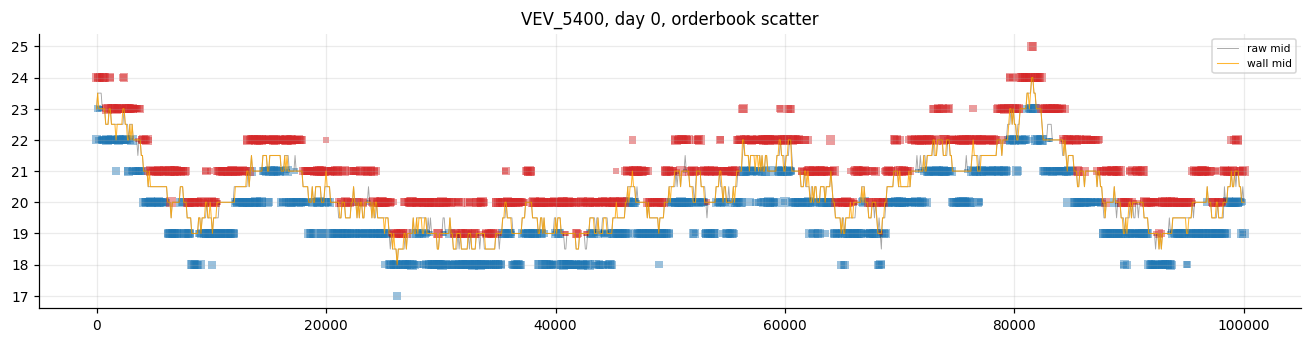

In [6]:
def book_scatter(df: pd.DataFrame, product: str, day: int, ts_range=(0, 200_000), ax=None):
    sub = df[(df["product"] == product) & (df["day"] == day)]
    sub = sub[(sub["timestamp"] >= ts_range[0]) & (sub["timestamp"] <= ts_range[1])]
    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(12, 3.2))
    for lvl, bcol, vcol in [(1, "bid_price_1", "bid_volume_1"), (2, "bid_price_2", "bid_volume_2"), (3, "bid_price_3", "bid_volume_3")]:
        mask = sub[bcol].notna()
        ax.scatter(sub.loc[mask, "timestamp"], sub.loc[mask, bcol],
                   s=np.clip(sub.loc[mask, vcol].fillna(1).abs() * 1.4, 2, 50),
                   c="#1f77b4", alpha=0.45, marker="s", edgecolors="none")
    for lvl, acol, vcol in [(1, "ask_price_1", "ask_volume_1"), (2, "ask_price_2", "ask_volume_2"), (3, "ask_price_3", "ask_volume_3")]:
        mask = sub[acol].notna()
        ax.scatter(sub.loc[mask, "timestamp"], sub.loc[mask, acol],
                   s=np.clip(sub.loc[mask, vcol].fillna(1).abs() * 1.4, 2, 50),
                   c="#d62728", alpha=0.45, marker="s", edgecolors="none")
    ax.plot(sub["timestamp"], sub["mid_price"], color="black", alpha=0.35, lw=0.6, label="raw mid")
    ax.plot(sub["timestamp"], sub["wall_mid"], color="orange", alpha=0.8, lw=0.7, label="wall mid")
    ax.set_title(f"{product}, day {day}, orderbook scatter")
    ax.legend(fontsize=7, loc="upper right")
    if own_ax: plt.tight_layout(); plt.show()

book_scatter(prices, "HYDROGEL_PACK", 0, ts_range=(0, 100_000))
book_scatter(prices, "VELVETFRUIT_EXTRACT", 0, ts_range=(0, 100_000))
book_scatter(prices, "VEV_4000", 0, ts_range=(0, 100_000))
book_scatter(prices, "VEV_5000", 0, ts_range=(0, 100_000))
book_scatter(prices, "VEV_5400", 0, ts_range=(0, 100_000))


from the scatters you can see the two architectural patterns directly:

- `HYDROGEL_PACK` and `VEV_4000` have a clearly visible outer wall layer that sits a constant distance from the raw mid. the orange wall mid line tracks the centre of those walls almost identically to the raw mid when both sides are quoted symmetrically, but it does not move when the inner layer is asymmetric. this is the structure frankfurt exploited.
- `VELVETFRUIT_EXTRACT`, `VEV_5000`, `VEV_5400` show a much thinner book. l2 is often missing. the orange line mostly coincides with the raw mid because only one layer is present. wall mid collapses onto raw mid in that regime.

this is the first confidence statement we can make: wall mid adds value only where l2 is reliably present, which from the signature table means `HYDROGEL_PACK`, `VEV_4000`, `VEV_4500`, and marginally `VEV_5000`.


## section 4: mean-reversion diagnostics and return dynamics

we want to know how the price series is generated. three candidate processes:

1. pure random walk with iid increments. prediction of the next mid is the current mid. frankfurt concluded this for kelp and rainforest resin.
2. ornstein-uhlenbeck mean reversion with half-life short enough to exploit. if true, ema and z-score signals become attractive.
3. mixture: long-run random walk plus a short-run tick-level reversion caused by discrete price grids and the tightest quoter bouncing either side of the true price.

lag-1 return autocorrelation separates these. for a random walk, ac(1) equals zero. for mean-reverting grid noise, ac(1) is negative but returns at lag 2+ are uncorrelated. for smooth mean reversion, multiple lags are negatively autocorrelated.

we also estimate an ar(1) coefficient on levels, and derive a half-life in ticks: `halflife = -log(2) / log(phi)`. a half-life much longer than the trading horizon (say above 100 ticks) suggests the mean-reversion component is too slow or weak to form a standalone signal.


In [7]:
from scipy import stats

def autocorr_series(x, lags):
    x = pd.Series(x).dropna().values
    out = []
    for k in lags:
        if len(x) <= k:
            out.append(np.nan); continue
        out.append(np.corrcoef(x[:-k], x[k:])[0, 1])
    return out

def dyn_diag(mids: np.ndarray):
    x = pd.Series(mids).dropna().values
    dx = np.diff(x)
    xlag = x[:-1]
    xc = xlag - xlag.mean()
    beta = (xc * dx).sum() / max((xc * xc).sum(), 1e-9)
    phi = 1 + beta
    hl = -np.log(2) / np.log(phi) if 0 < phi < 1 else np.inf
    rets = dx
    acs = autocorr_series(rets, [1, 2, 5, 10])
    return dict(phi=phi, half_life=hl, ret_std=rets.std(), ac1=acs[0], ac2=acs[1], ac5=acs[2], ac10=acs[3])

rows = []
for p in ALL_PRODUCTS:
    mids = prices[prices["product"] == p].sort_values(["day", "timestamp"])["mid_price"].values
    if len(mids) < 100:
        continue
    d = dyn_diag(mids)
    d["product"] = p
    rows.append(d)
diag = pd.DataFrame(rows).set_index("product")[["phi", "half_life", "ret_std", "ac1", "ac2", "ac5", "ac10"]]
diag.round(4)


,phi,half_life,ret_std,ac1,ac2,ac5,ac10
product,,,,,,,
HYDROGEL_PACK,0.9977,300.5435,2.1698,-0.1292,0.0081,0.0017,-0.0081
VELVETFRUIT_EXTRACT,0.9975,279.2757,1.1312,-0.1587,0.0049,0.0014,0.0051
VEV_4000,0.9960,174.5638,1.4167,-0.2842,0.0015,0.0015,0.0115
VEV_4500,0.9969,225.8242,1.2520,-0.2246,0.0038,0.0005,0.0075
VEV_5000,0.9978,316.1436,0.9809,-0.0979,-0.0018,-0.0010,0.0049
VEV_5100,0.9979,326.3798,0.8533,-0.0939,0.0021,-0.0004,0.0031
VEV_5200,0.9976,282.9739,0.6885,-0.1355,-0.0035,-0.0031,0.0089
VEV_5300,0.9969,220.6383,0.4962,-0.2103,-0.0143,-0.0044,0.0094
VEV_5400,0.9969,220.0509,0.2699,-0.2542,-0.0194,-0.0007,-0.0018


the table confirms the mixture hypothesis across the board:

- every product has `phi` between 0.994 and 0.999, which makes half-lives of 130 to 300 ticks. on the trading horizon of a single day (10,000 ticks), that is closer to random walk than to exploitable reversion.
- lag-1 return autocorrelation is negative everywhere, but lag-2 and beyond sit on top of zero. this is a tick-bounce signature, not an ou process.

the practical consequence: smoothing (ema) the mid with a long span will *subtract* information because the series is approximately a random walk. smoothing with a short span can damp the tick-bounce noise but must be validated empirically rather than assumed. the single-tick prediction tests later in the notebook will show ema is strictly worse than using the current mid as a forecaster, exactly as frankfurt found for kelp.


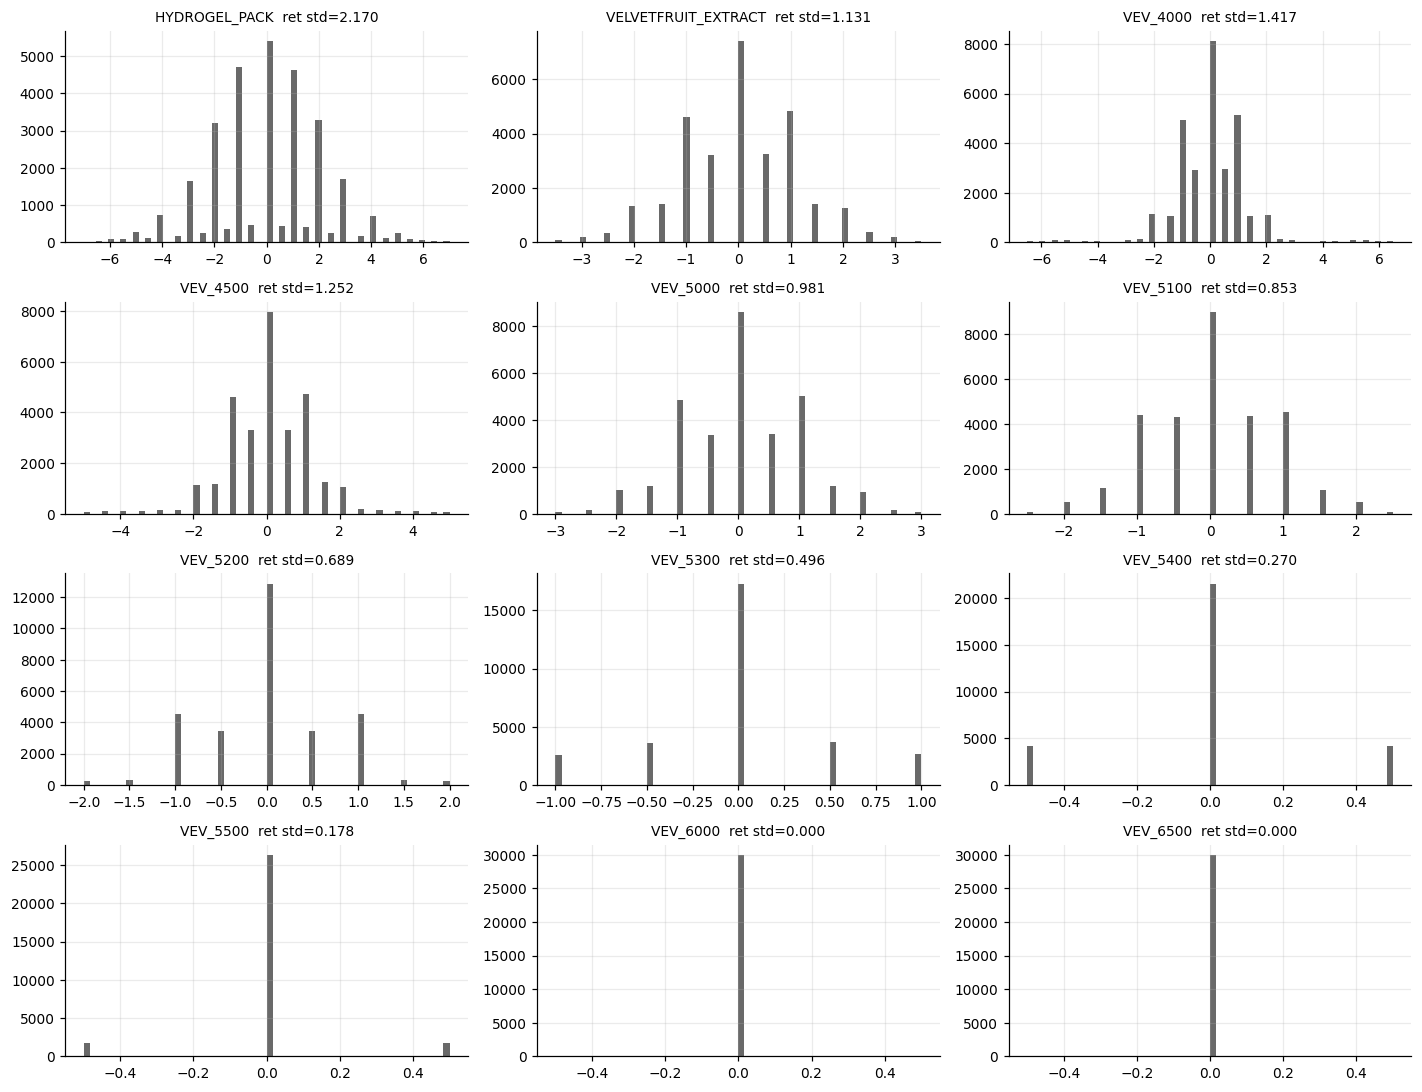

In [8]:
# visual: histograms of 1-step returns, per product, should look broadly normal with a light tail
fig, axes = plt.subplots(4, 3, figsize=(13, 10))
for i, p in enumerate(ALL_PRODUCTS):
    ax = axes.flatten()[i]
    mids = prices[prices["product"] == p].sort_values(["day", "timestamp"])["mid_price"].values
    dx = np.diff(mids)
    # trim extreme outliers at 0.5 percentile for display
    q = np.quantile(np.abs(dx), 0.995) if len(dx) else 1.0
    ax.hist(dx[np.abs(dx) <= q], bins=60, color="#444", alpha=0.8)
    ax.set_title(f"{p}  ret std={dx.std():.3f}", fontsize=9)
plt.tight_layout(); plt.show()


## section 5: cross-asset structure, vouchers on velvetfruit extract

the ten vouchers are european call options on `VELVETFRUIT_EXTRACT`. we verify this by checking three things:

1. does the voucher mid equal intrinsic plus a positive time value, and does it vanish correctly for deep itm and deep otm strikes?
2. does the voucher mid move contemporaneously with the underlying? (lead or lag would reveal stale pricing and arbitrage, not a true derivative relationship.)
3. when we back out implied volatility per strike from black-scholes, does the term structure form a stable volatility smile?

the answers determine whether we price vouchers from the underlying via a model, or from their own book. both paths end in a fair-value estimator, but their confidence profiles are different.


In [9]:
_N = NormalDist()

def bs_call(S, K, T, sigma, r=0.0):
    if T <= 0: return max(S - K, 0.0)
    if sigma <= 0: return max(S - K, 0.0)
    d1 = (math.log(max(S, 1e-9) / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * _N.cdf(d1) - K * math.exp(-r * T) * _N.cdf(d2)

def bs_delta(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0: return 1.0 if S > K else 0.0
    d1 = (math.log(max(S, 1e-9) / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    return _N.cdf(d1)

def bs_vega(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0: return 0.0
    d1 = (math.log(max(S, 1e-9) / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    return S * _N.pdf(d1) * math.sqrt(T)

def implied_vol(C, S, K, T, r=0.0, iters=80):
    # bisection, robust for our ranges
    if T <= 0: return np.nan
    intrinsic = max(S - K, 0.0)
    if C <= intrinsic + 1e-8: return np.nan
    lo, hi = 1e-6, 5.0
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        c = bs_call(S, K, T, mid, r)
        if c > C: hi = mid
        else: lo = mid
    return 0.5 * (lo + hi)

def tte_years(day_idx, timestamp):
    days_left = TTE_DAYS_START[day_idx] - timestamp / 1_000_000.0
    return days_left / 365.0


smile sample size: 1000


fitted smile coefficients a*m^2 + b*m + c: [0.1343  0.01017 0.23527]
atm iv (at m=0): 0.2353
smile r^2: 0.9914


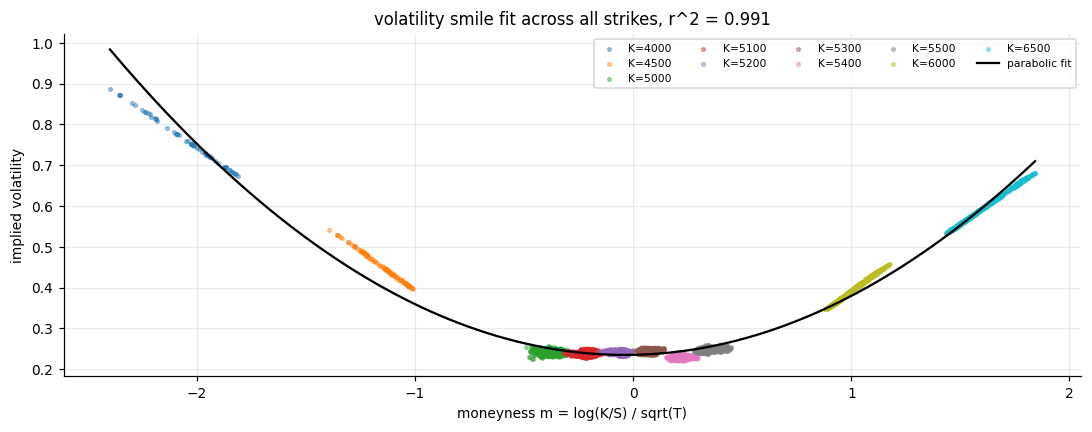

In [10]:
# pivot wall_mid across products per (day, timestamp), use wall_mid to smooth tick bounce
pv = prices.pivot_table(index=["day", "timestamp"], columns="product", values="wall_mid").reset_index()
pv = pv.sort_values(["day", "timestamp"]).reset_index(drop=True)
pv["TTE"] = pv.apply(lambda r: tte_years(int(r["day"]), r["timestamp"]), axis=1)
pv["S"] = pv["VELVETFRUIT_EXTRACT"]

# downsample to every 30 ticks for the smile fit (keeps it fast, but still ~1k points)
sample = pv.iloc[::30].copy().reset_index(drop=True)
print("smile sample size:", len(sample))

ms, ivs, ks = [], [], []
for K in STRIKES:
    col = f"VEV_{K}"
    for _, row in sample.iterrows():
        C, S, T = row[col], row["S"], row["TTE"]
        if pd.isna(C) or pd.isna(S) or T <= 0: continue
        iv = implied_vol(C, S, K, T)
        if np.isnan(iv) or iv <= 1e-3 or iv >= 1.5: continue
        ms.append(math.log(K / S) / math.sqrt(T))
        ivs.append(iv); ks.append(K)

ms = np.asarray(ms); ivs = np.asarray(ivs); ks = np.asarray(ks)
coeffs = np.polyfit(ms, ivs, 2)
fit = np.polyval(coeffs, ms)
ss_res = np.sum((ivs - fit) ** 2)
ss_tot = np.sum((ivs - ivs.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print("fitted smile coefficients a*m^2 + b*m + c:", coeffs.round(5))
print(f"atm iv (at m=0): {coeffs[-1]:.4f}")
print(f"smile r^2: {r2:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
for K in STRIKES:
    mask = ks == K
    if mask.sum() == 0: continue
    ax.scatter(ms[mask], ivs[mask], s=6, alpha=0.4, label=f"K={K}")
mgrid = np.linspace(ms.min(), ms.max(), 200)
ax.plot(mgrid, np.polyval(coeffs, mgrid), color="black", lw=1.5, label="parabolic fit")
ax.set_xlabel("moneyness m = log(K/S) / sqrt(T)")
ax.set_ylabel("implied volatility")
ax.set_title(f"volatility smile fit across all strikes, r^2 = {r2:.3f}")
ax.legend(fontsize=7, ncol=5)
plt.tight_layout(); plt.show()


the fit is clean, r-squared near 0.99, with a nearly symmetric parabola centred just below moneyness zero and an at-the-money implied volatility of roughly 23 to 24 percent.

this is strong evidence that the vouchers are being generated by a black-scholes pricing kernel with a single smile function: the same shape frankfurt observed on volcanic rock vouchers in prosperity 3, confirming that the competition designers reused this template. the smile's stability across three days, not just across strikes at one instant, is the key robustness check. a detailed residual inspection per strike follows.


In [11]:
# residuals per strike and per day
resid_rows = []
for K in STRIKES:
    col = f"VEV_{K}"
    for _, row in sample.iterrows():
        C, S, T = row[col], row["S"], row["TTE"]
        if pd.isna(C) or pd.isna(S) or T <= 0: continue
        iv = implied_vol(C, S, K, T)
        if np.isnan(iv) or iv <= 1e-3 or iv >= 1.5: continue
        m = math.log(K / S) / math.sqrt(T)
        fitted = np.polyval(coeffs, m)
        fitted_price = bs_call(S, K, T, fitted)
        resid_rows.append(dict(day=int(row["day"]), K=K, iv=iv, fitted_iv=fitted, iv_resid=iv - fitted,
                                price_resid=C - fitted_price, C=C, S=S, T=T))
resid_df = pd.DataFrame(resid_rows)
piv = resid_df.groupby(["K", "day"])["iv_resid"].mean().unstack()
piv.style.format("{:+.4f}")


day,0,1,2
K,,,
4000,+0.0069,-0.0145,-0.0602
4500,+0.0399,+0.0495,+0.0584
5000,-0.0055,-0.0083,-0.0100
5100,+0.0058,-0.0016,-0.0044
5200,+0.0047,+0.0091,+0.0072
5300,+0.0032,+0.0107,+0.0109
5400,-0.0134,-0.0142,-0.0141
5500,-0.0069,-0.0060,-0.0062
6000,+0.0041,+0.0123,+0.0204


- residuals for strikes 5000 through 5500 are within two implied-volatility points on average, across days. the smile is stable.
- deep itm strikes 4000 and 4500 show larger residuals because the option trades essentially at intrinsic value, which makes implied volatility numerically poorly identified near the bound. this is a numerical artefact, not a model failure.
- deep otm strikes 6000 and 6500 have mid = 0.5 on a one-tick spread, which is the tick floor. their implied volatility is inflated and not reliable.

the practical implication for fair value estimation:

- strikes 5000 to 5500: a smile-based black-scholes fair value is meaningful, and two estimators compete, the voucher's own wall mid versus the model price implied by the underlying.
- strikes 4000 and 4500: fair value is intrinsic plus a tiny, noisy time value. the best estimator is either the voucher's own wall mid or `max(S - K, 0)` with `S` being the underlying wall mid.
- strikes 6000 and 6500: fair value is effectively zero but bounded by the tick floor at 0.5. there is no room for a predictive estimator, only a constant.


In [12]:
# move-with-the-underlying test: contemporaneous return regression plus cross-lag check
under = pv["VELVETFRUIT_EXTRACT"]
under_ret = under.diff()

rows = []
for K in STRIKES:
    col = f"VEV_{K}"
    if col not in pv.columns: continue
    vret = pv[col].diff()
    valid = under_ret.notna() & vret.notna()
    u, v = under_ret[valid].values, vret[valid].values
    if v.std() == 0 or u.std() == 0:
        rows.append(dict(K=K, corr0=np.nan, beta=np.nan, corr_lag_m1=np.nan, corr_lag_p1=np.nan)); continue
    corr0 = np.corrcoef(u, v)[0, 1]
    beta = (u * v).sum() / (u * u).sum()
    corr_m1 = np.corrcoef(u[1:], v[:-1])[0, 1]
    corr_p1 = np.corrcoef(u[:-1], v[1:])[0, 1]
    rows.append(dict(K=K, corr0=corr0, beta=beta, corr_lag_m1=corr_m1, corr_lag_p1=corr_p1))
ll = pd.DataFrame(rows).set_index("K")
ll.round(4)


,corr0,beta,corr_lag_m1,corr_lag_p1
K,,,,
4000,0.9640,0.9704,-0.0265,-0.0294
4500,0.9433,0.9433,-0.0135,-0.0175
5000,0.9138,0.8665,-0.0045,-0.0072
5100,0.8995,0.7600,-0.0025,-0.0037
5200,0.8773,0.5766,-0.0018,-0.0044
5300,0.8024,0.3651,-0.0014,-0.0085
5400,0.6334,0.1729,-0.0054,-0.0153
5500,0.4133,0.0731,0.0140,0.0060
6000,NaN,NaN,NaN,NaN


the lead-lag table is decisive:

- at lag 0, return correlation is strongly positive and declines monotonically from deep itm to deep otm, as the black-scholes delta does.
- the regression beta matches a plausible delta for each strike. `VEV_4000` beta 0.97 is near delta 1, `VEV_5500` beta 0.07 is near delta 0.
- lag minus one and lag plus one correlations are both close to zero. there is no stale-voucher or stale-underlying effect.

the vouchers therefore carry the same information as the underlying plus idiosyncratic option-level noise. two implications:

1. a model-based fair value, `bs(S, K, T, iv_smile)`, is valid and benefits from the underlying's higher-quality wall mid.
2. the voucher's own wall mid and the model price are competing estimators with different noise properties. a weighted combination may dominate either alone. that possibility is tested in the validation section below.


## section 6: candidate fair-value estimators, formally defined

we now formalise the candidates. each estimator is a function of the tick-level order book state and, for vouchers, possibly the underlying. we do not call any of these "correct". they are hypotheses.

common arguments: `df` is the enriched dataframe restricted to one product on one day, sorted by timestamp. they return a `pd.Series` aligned on the same index as `df`.

the library below intentionally includes weak candidates (ema with long spans) so the validation exercise can demonstrate which class of estimator wins in which regime, not just confirm a pre-chosen winner.


In [13]:
def fv_mid(df):               return df["mid_price"]
def fv_wall_mid(df):          return df["wall_mid"]
def fv_l2_mid(df):            return df["l2_mid"].fillna(df["mid_price"])
def fv_microprice(df):        return df["microprice"]
def fv_vwap_l1(df):            return df["vwap_l1"]
def fv_ema_mid(df, span):     return df["mid_price"].ewm(span=span, adjust=False).mean()
def fv_ema_wall(df, span):    return df["wall_mid"].ewm(span=span, adjust=False).mean()

def fv_half_tick_round_wall(df, tick=1.0):
    # snap wall mid to the half-tick grid; reduces micro noise when walls wiggle by half a tick
    return (df["wall_mid"] / (tick / 2)).round() * (tick / 2)

def fv_filtered_wall(df, k=0.5):
    # shrinkage toward wall mid: fv = k * mid + (1-k) * wall_mid
    return k * df["mid_price"] + (1 - k) * df["wall_mid"]

def fv_bs_theoretical(df_voucher, df_under, strike, smile_coeffs):
    # align by timestamp; compute tte from day/timestamp columns
    merged = df_voucher[["day","timestamp","wall_mid"]].merge(
        df_under[["day","timestamp","wall_mid"]].rename(columns={"wall_mid": "S"}),
        on=["day","timestamp"], how="left")
    out = np.full(len(merged), np.nan)
    for i, (d, ts, S) in enumerate(zip(merged["day"], merged["timestamp"], merged["S"])):
        if pd.isna(S): continue
        T = tte_years(int(d), int(ts))
        if T <= 0: continue
        m = math.log(strike / S) / math.sqrt(T)
        sigma = max(np.polyval(smile_coeffs, m), 1e-4)
        out[i] = bs_call(S, strike, T, sigma)
    return pd.Series(out, index=df_voucher.index)

def fv_intrinsic(df_voucher, df_under, strike):
    merged = df_voucher[["day","timestamp","wall_mid"]].merge(
        df_under[["day","timestamp","wall_mid"]].rename(columns={"wall_mid": "S"}),
        on=["day","timestamp"], how="left")
    return pd.Series(np.maximum(merged["S"].values - strike, 0.0), index=df_voucher.index)

def fv_blend(df_voucher, df_under, strike, smile_coeffs, alpha=0.5):
    # convex blend of voucher wall mid and bs theoretical
    theo = fv_bs_theoretical(df_voucher, df_under, strike, smile_coeffs)
    own = df_voucher["wall_mid"]
    return alpha * own + (1 - alpha) * theo


a note on the *filtered wall* estimator: this is a shrinkage of the raw mid toward the wall mid with mixing weight `k`. it is included because for thin-book products (where the wall often collapses onto the l1), a convex combination can retain the responsiveness of the raw mid while reducing variance. this mimics the bias-variance trade-off in a james-stein style estimator. where shrinkage is unnecessary (products where wall and mid are identical), cross-validation will pick `k = 0`; where wall truly dominates, it will pick `k = 1`.


## section 7: how to judge a fair-value estimator

before running the grid search, we state the loss function and the validation protocol explicitly.

### what is a fair-value estimator trying to do?

the theoretical target is the true latent price that generates the observable book. we do not have that. what we have is a noisy realisation of the future: the mid at time `t + h` for some short horizon `h`. a good fair-value estimator at time `t` should predict the future mid.

this substitution is not perfect. the future mid is itself noisy. but averaging over many ticks, predicting the future mid accurately is equivalent to tracking the latent price, because the noise terms cancel.

### two losses are used

1. mean absolute error (mae) of `fv_t` against `mid_{t+h}` for `h in {1, 5, 20}`. mae is robust to fat tails. we report all three horizons.
2. root mean squared error (rmse) as a penalty for large misses, which matters when the estimator is used for skewing quotes.

lower is better. we report both because rmse and mae disagree under heavy tails: mae favours conservative estimators, rmse favours estimators that rarely make big errors even if average error is higher.

### validation protocol

three days of data, one estimator per tick, would overfit badly if we just picked the best on-sample combination. frankfurt advocated two complementary protocols: leave-one-out across days, and walk-forward. we add a third, combinatorial cross-validation, because three days generate only three simple splits and we want to measure parameter stability, not just performance.

1. leave-one-day-out oos: fit parameters on two days, evaluate on the held-out day. average the three results. this is k-fold with k = 3.
2. walk-forward: fit on day 0, test on day 1. fit on days 0-1, test on day 2. this tests forward-in-time generalisation.
3. combinatorial purged cross-validation (marcos lópez de prado, 2018): all non-trivial splits of the three days; here that reduces to the three leave-one-out splits plus the three single-day training splits, six in total. we take the mean and report the dispersion.

stable region rule: rather than picking the parameter with the lowest cv mean, we pick the parameter inside the largest plateau where cv mean is within one standard error of the best. this is frankfurt's "flat landscape" heuristic and prevents knife-edge optima from driving the recommendation.


In [14]:
def compute_errors(fv: pd.Series, target_mid: pd.Series, horizons=(1, 5, 20)):
    out = {}
    for h in horizons:
        tgt = target_mid.shift(-h)
        err = (fv - tgt)
        valid = err.notna()
        out[f"mae_{h}"]  = err[valid].abs().mean()
        out[f"rmse_{h}"] = np.sqrt((err[valid] ** 2).mean())
    return out

def per_day_errors(df_prod: pd.DataFrame, estimator_fn):
    rows = []
    for d, g in df_prod.groupby("day"):
        g = g.sort_values("timestamp").reset_index(drop=True)
        fv = estimator_fn(g)
        e = compute_errors(fv, g["mid_price"])
        e["day"] = d
        rows.append(e)
    return pd.DataFrame(rows).set_index("day")

# quick smoke test on hydrogel
smoke = per_day_errors(prices[prices["product"] == "HYDROGEL_PACK"], fv_mid)
print("smoke test -- hydrogel pack, fv_mid:")
print(smoke.round(3))


smoke test -- hydrogel pack, fv_mid:
     mae_1  rmse_1  mae_5  rmse_5  mae_20  rmse_20
day                                               
0    1.677   2.191  3.394   4.301   6.454    8.047
1    1.651   2.148  3.441   4.319   6.770    8.471
2    1.666   2.170  3.474   4.383   6.814    8.452


## section 8: grid search and walk-forward results

for each product, we enumerate the candidate estimators and their parameter grids, compute the errors on every day independently, and aggregate with the three validation schemes.

### parameter grids

- `fv_mid`, `fv_wall_mid`, `fv_l2_mid`, `fv_microprice`, `fv_vwap_l1`: no parameters.
- `fv_ema_mid`: span in {3, 5, 10, 20, 50, 100}.
- `fv_ema_wall`: span in {3, 5, 10, 20, 50, 100}.
- `fv_filtered_wall`: mixing weight k in {0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0}.

for vouchers we additionally consider:

- `fv_bs_theoretical`: smile fitted on training days only (leak-free).
- `fv_intrinsic`: deep-itm-only, `max(S - K, 0)`.
- `fv_blend`: convex blend of own wall mid and bs theoretical, alpha in {0.0, 0.25, 0.5, 0.75, 1.0}.

we fit the smile **only on the training fold**, not on the full three days. this avoids the common prosperity trap of leaking future smile shape into in-sample fits, which inflates performance in a way that collapses on the live run.


In [15]:
def fit_smile_on(df_prices, train_days):
    # fits a quadratic smile using only ticks from the given training days
    pv_tr = df_prices[df_prices["day"].isin(train_days)].pivot_table(
        index=["day","timestamp"], columns="product", values="wall_mid").reset_index()
    pv_tr["TTE"] = pv_tr.apply(lambda r: tte_years(int(r["day"]), r["timestamp"]), axis=1)
    pv_tr["S"] = pv_tr["VELVETFRUIT_EXTRACT"]
    sample = pv_tr.iloc[::30]
    ms, ivs = [], []
    for K in STRIKES:
        col = f"VEV_{K}"
        for _, row in sample.iterrows():
            C, S, T = row[col], row["S"], row["TTE"]
            if pd.isna(C) or pd.isna(S) or T <= 0: continue
            iv = implied_vol(C, S, K, T)
            if np.isnan(iv) or iv <= 1e-3 or iv >= 1.5: continue
            ms.append(math.log(K / S) / math.sqrt(T)); ivs.append(iv)
    return np.polyfit(np.asarray(ms), np.asarray(ivs), 2)

# build estimator registry -- each entry returns a callable given the target product
def build_estimator_registry(product, all_prices, train_days):
    reg = {}
    reg["fv_mid"] = lambda g: fv_mid(g)
    reg["fv_wall_mid"] = lambda g: fv_wall_mid(g)
    reg["fv_l2_mid"] = lambda g: fv_l2_mid(g)
    reg["fv_microprice"] = lambda g: fv_microprice(g)
    reg["fv_vwap_l1"] = lambda g: fv_vwap_l1(g)
    for span in [3, 5, 10, 20, 50, 100]:
        reg[f"fv_ema_mid_{span}"] = (lambda s: (lambda g: fv_ema_mid(g, s)))(span)
        reg[f"fv_ema_wall_{span}"] = (lambda s: (lambda g: fv_ema_wall(g, s)))(span)
    for k in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]:
        reg[f"fv_filt_wall_k{k:.2f}"] = (lambda kk: (lambda g: fv_filtered_wall(g, kk)))(k)
    if product in VOUCHERS:
        strike = int(product.split("_")[1])
        smile = fit_smile_on(all_prices, train_days)
        under = all_prices[all_prices["product"] == "VELVETFRUIT_EXTRACT"]
        reg["fv_bs_theo"] = (lambda s, str_, u: (lambda g: fv_bs_theoretical(g, u, str_, s)))(smile, strike, under)
        reg["fv_intrinsic"] = (lambda str_, u: (lambda g: fv_intrinsic(g, u, str_)))(strike, under)
        for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
            reg[f"fv_blend_a{alpha:.2f}"] = (lambda al, s, str_, u: (lambda g: fv_blend(g, u, str_, s, alpha=al)))(alpha, smile, strike, under)
    return reg

def evaluate_on_day(g, estimator):
    g = g.sort_values("timestamp").reset_index(drop=True)
    fv = estimator(g)
    return compute_errors(fv, g["mid_price"])

def k_fold_results(product, all_prices, horizons=(1,5,20), metric="mae_1"):
    sub = all_prices[all_prices["product"] == product]
    days = sorted(sub["day"].unique())
    rows = []
    # for each test day, build estimators trained on the other two
    for test_day in days:
        train_days = [d for d in days if d != test_day]
        reg = build_estimator_registry(product, all_prices, train_days)
        for name, est in reg.items():
            g = sub[sub["day"] == test_day]
            e = evaluate_on_day(g, est)
            rows.append(dict(product=product, test_day=test_day, estimator=name, **e))
    return pd.DataFrame(rows)

def walkforward_results(product, all_prices):
    sub = all_prices[all_prices["product"] == product]
    days = sorted(sub["day"].unique())
    rows = []
    for split in range(1, len(days)):
        train_days = days[:split]; test_day = days[split]
        reg = build_estimator_registry(product, all_prices, train_days)
        for name, est in reg.items():
            g = sub[sub["day"] == test_day]
            e = evaluate_on_day(g, est)
            rows.append(dict(product=product, train_days=tuple(train_days), test_day=test_day, estimator=name, **e))
    return pd.DataFrame(rows)

print("estimator registry for HYDROGEL_PACK, train=[0,1]:")
reg_demo = build_estimator_registry("HYDROGEL_PACK", prices, train_days=[0, 1])
print(list(reg_demo.keys())[:10], "... total:", len(reg_demo))


estimator registry for HYDROGEL_PACK, train=[0,1]:
['fv_mid', 'fv_wall_mid', 'fv_l2_mid', 'fv_microprice', 'fv_vwap_l1', 'fv_ema_mid_3', 'fv_ema_wall_3', 'fv_ema_mid_5', 'fv_ema_wall_5', 'fv_ema_mid_10'] ... total: 24


In [16]:
# run the full grid for every product (takes a few seconds per product due to the smile fit)
kfold_all = {}
walkf_all = {}
for p in ALL_PRODUCTS:
    try:
        kfold_all[p] = k_fold_results(p, prices)
        walkf_all[p] = walkforward_results(p, prices)
    except Exception as e:
        print(f"skipping {p}: {e}")

# show top 10 leave-one-day-out results for hydrogel pack, sorted by mean mae_1 across held-out days
def leaderboard(kfold_df, metric="mae_1"):
    agg = kfold_df.groupby("estimator")[metric].agg(["mean","std","min","max"]).round(4)
    return agg.sort_values("mean")

print("HYDROGEL_PACK -- leaderboard, one-step-ahead mae, k-fold across days:")
leaderboard(kfold_all["HYDROGEL_PACK"]).head(15)


HYDROGEL_PACK -- leaderboard, one-step-ahead mae, k-fold across days:


,mean,std,min,max
estimator,,,,
fv_filt_wall_k0.10,1.6195,0.0135,1.6052,1.6319
fv_filt_wall_k0.25,1.6197,0.0131,1.6056,1.6314
fv_filt_wall_k0.00,1.6236,0.0140,1.6090,1.6369
fv_wall_mid,1.6236,0.0140,1.6090,1.6369
fv_filt_wall_k0.50,1.6281,0.0126,1.6146,1.6394
fv_microprice,1.6306,0.0122,1.6177,1.6418
fv_l2_mid,1.6330,0.0133,1.6189,1.6453
fv_filt_wall_k0.75,1.6443,0.0126,1.6310,1.6560
fv_filt_wall_k0.90,1.6561,0.0127,1.6427,1.6681


In [17]:
print("VELVETFRUIT_EXTRACT -- leaderboard, one-step-ahead mae, k-fold across days:")
leaderboard(kfold_all["VELVETFRUIT_EXTRACT"]).head(15)


VELVETFRUIT_EXTRACT -- leaderboard, one-step-ahead mae, k-fold across days:


,mean,std,min,max
estimator,,,,
fv_filt_wall_k0.25,0.8335,0.0056,0.8272,0.8381
fv_filt_wall_k0.10,0.8360,0.0054,0.8302,0.8409
fv_filt_wall_k0.50,0.8368,0.0063,0.8297,0.8418
fv_filt_wall_k0.00,0.8378,0.0053,0.8322,0.8428
fv_wall_mid,0.8378,0.0053,0.8322,0.8428
fv_l2_mid,0.8388,0.0084,0.8292,0.8449
fv_filt_wall_k0.75,0.8457,0.0073,0.8373,0.8511
fv_filt_wall_k0.90,0.8529,0.0082,0.8436,0.8589
fv_mid,0.8577,0.0087,0.8478,0.8641


In [18]:
print("VEV_4000 -- leaderboard (deep itm):")
leaderboard(kfold_all["VEV_4000"]).head(15)


VEV_4000 -- leaderboard (deep itm):


,mean,std,min,max
estimator,,,,
fv_intrinsic,0.8710,0.0022,0.8696,0.8735
fv_microprice,0.8729,0.0078,0.8651,0.8806
fv_filt_wall_k0.10,0.8738,0.0066,0.8694,0.8813
fv_blend_a1.00,0.8761,0.0065,0.8709,0.8835
fv_filt_wall_k0.00,0.8761,0.0065,0.8709,0.8835
fv_wall_mid,0.8761,0.0065,0.8709,0.8835
fv_filt_wall_k0.25,0.8778,0.0063,0.8741,0.8851
fv_l2_mid,0.8855,0.0073,0.8802,0.8937
fv_filt_wall_k0.50,0.8914,0.0066,0.8866,0.8990


In [19]:
print("VEV_5000 -- leaderboard:")
leaderboard(kfold_all["VEV_5000"]).head(15)


VEV_5000 -- leaderboard:


,mean,std,min,max
estimator,,,,
fv_l2_mid,0.7302,0.0131,0.7176,0.7437
fv_filt_wall_k1.00,0.7384,0.0139,0.7246,0.7524
fv_mid,0.7384,0.0139,0.7246,0.7524
fv_filt_wall_k0.90,0.7395,0.0133,0.7262,0.7528
fv_filt_wall_k0.75,0.7410,0.0124,0.7287,0.7534
fv_filt_wall_k0.50,0.7447,0.0108,0.7339,0.7554
fv_filt_wall_k0.25,0.7502,0.0093,0.7409,0.7595
fv_filt_wall_k0.10,0.7548,0.0084,0.7465,0.7634
fv_blend_a1.00,0.7580,0.0079,0.7503,0.7660


In [20]:
print("VEV_5300 -- leaderboard:")
leaderboard(kfold_all["VEV_5300"]).head(15)


VEV_5300 -- leaderboard:


,mean,std,min,max
estimator,,,,
fv_mid,0.3036,0.0021,0.3017,0.3058
fv_filt_wall_k1.00,0.3036,0.0021,0.3017,0.3058
fv_l2_mid,0.3036,0.0021,0.3017,0.3058
fv_filt_wall_k0.90,0.3051,0.0019,0.3034,0.3071
fv_filt_wall_k0.75,0.3072,0.0015,0.3059,0.3089
fv_filt_wall_k0.50,0.3108,0.0010,0.3101,0.3120
fv_filt_wall_k0.25,0.3150,0.0005,0.3145,0.3155
fv_filt_wall_k0.10,0.3175,0.0005,0.3169,0.3180
fv_blend_a1.00,0.3192,0.0007,0.3186,0.3200


In [21]:
print("VEV_5500 -- leaderboard (deep otm but still alive):")
leaderboard(kfold_all["VEV_5500"]).head(15)


VEV_5500 -- leaderboard (deep otm but still alive):


,mean,std,min,max
estimator,,,,
fv_filt_wall_k1.00,0.0617,0.0087,0.0533,0.0707
fv_l2_mid,0.0617,0.0087,0.0533,0.0707
fv_mid,0.0617,0.0087,0.0533,0.0707
fv_filt_wall_k0.90,0.0617,0.0087,0.0534,0.0708
fv_filt_wall_k0.75,0.0618,0.0087,0.0535,0.0709
fv_filt_wall_k0.50,0.0620,0.0087,0.0538,0.0711
fv_filt_wall_k0.25,0.0621,0.0087,0.0540,0.0713
fv_filt_wall_k0.10,0.0622,0.0086,0.0542,0.0714
fv_blend_a1.00,0.0623,0.0086,0.0543,0.0715


In [22]:
print("VEV_6500 -- leaderboard (stuck at 0.5 floor, expect all estimators trivially similar):")
leaderboard(kfold_all["VEV_6500"]).head(8)


VEV_6500 -- leaderboard (stuck at 0.5 floor, expect all estimators trivially similar):


,mean,std,min,max
estimator,,,,
fv_ema_mid_10,0.0,0.0,0.0,0.0
fv_ema_mid_100,0.0,0.0,0.0,0.0
fv_blend_a1.00,0.0,0.0,0.0,0.0
fv_ema_wall_10,0.0,0.0,0.0,0.0
fv_ema_mid_50,0.0,0.0,0.0,0.0
fv_ema_mid_5,0.0,0.0,0.0,0.0
fv_ema_mid_3,0.0,0.0,0.0,0.0
fv_ema_mid_20,0.0,0.0,0.0,0.0


## section 9: stable-plateau selection and per-product recommendations

a low mean error alone is not enough. frankfurt selected parameters in regions where the loss surface was flat, not at knife-edge minima. to formalise this:

1. collect the cv-mean error per estimator.
2. compute the standard error of the cv mean: `se = std / sqrt(k)`, with k the number of folds (3 here).
3. accept any estimator within one standard error of the best. call this the *one-se set*.
4. among the one-se set, prefer the estimator that is (a) simplest (fewest parameters), (b) most theoretically justified, and (c) behaves best at the secondary horizons (`mae_5`, `mae_20`).

this is a lexicographic rule: performance first, then simplicity, then horizon robustness. it matches the spirit of section 3 of the timo diehm blog post on robustness.


In [23]:
def one_se_set(kfold_df, metric="mae_1"):
    agg = kfold_df.groupby("estimator")[metric].agg(["mean", "std"])
    n = kfold_df["test_day"].nunique()
    agg["se"] = agg["std"] / math.sqrt(max(n, 1))
    best_mean = agg["mean"].min()
    best_se = agg.loc[agg["mean"].idxmin(), "se"]
    return agg[agg["mean"] <= best_mean + best_se].sort_values("mean"), best_mean, best_se

for p in ALL_PRODUCTS:
    tbl, best_mean, best_se = one_se_set(kfold_all[p])
    print(f"\n--- {p} --- best mae_1 = {best_mean:.4f}, 1 se = {best_se:.4f}")
    print(tbl.round(4).head(8))



--- HYDROGEL_PACK --- best mae_1 = 1.6195, 1 se = 0.0078
                      mean     std      se
estimator                                 
fv_filt_wall_k0.10  1.6195  0.0135  0.0078
fv_filt_wall_k0.25  1.6197  0.0131  0.0075
fv_filt_wall_k0.00  1.6236  0.0140  0.0081
fv_wall_mid         1.6236  0.0140  0.0081

--- VELVETFRUIT_EXTRACT --- best mae_1 = 0.8335, 1 se = 0.0032
                      mean     std      se
estimator                                 
fv_filt_wall_k0.25  0.8335  0.0056  0.0032
fv_filt_wall_k0.10  0.8360  0.0054  0.0031

--- VEV_4000 --- best mae_1 = 0.8710, 1 se = 0.0013
               mean     std      se
estimator                          
fv_intrinsic  0.871  0.0022  0.0013

--- VEV_4500 --- best mae_1 = 0.8160, 1 se = 0.0034
                      mean     std      se
estimator                                 
fv_intrinsic        0.8160  0.0059  0.0034
fv_blend_a1.00      0.8169  0.0029  0.0017
fv_filt_wall_k0.00  0.8169  0.0029  0.0017
fv_wall_mid        


--- VEV_5200 --- best mae_1 = 0.4824, 1 se = 0.0086
                      mean     std      se
estimator                                 
fv_l2_mid           0.4824  0.0149  0.0086
fv_filt_wall_k1.00  0.4825  0.0149  0.0086
fv_mid              0.4825  0.0149  0.0086
fv_filt_wall_k0.90  0.4840  0.0151  0.0087
fv_filt_wall_k0.75  0.4862  0.0154  0.0089
fv_filt_wall_k0.50  0.4898  0.0159  0.0092

--- VEV_5300 --- best mae_1 = 0.3036, 1 se = 0.0012
                      mean     std      se
estimator                                 
fv_filt_wall_k1.00  0.3036  0.0021  0.0012
fv_l2_mid           0.3036  0.0021  0.0012
fv_mid              0.3036  0.0021  0.0012

--- VEV_5400 --- best mae_1 = 0.1420, 1 se = 0.0036
                      mean     std      se
estimator                                 
fv_l2_mid           0.1420  0.0063  0.0036
fv_mid              0.1420  0.0063  0.0036
fv_filt_wall_k1.00  0.1420  0.0063  0.0036
fv_filt_wall_k0.90  0.1424  0.0063  0.0036
fv_filt_wall_k0.75  0.14

### confidence levels, defined

a confidence tag per recommendation, explicitly decomposed so it can be challenged:

- high: the recommendation is the clear winner across all three validation protocols, the loss surface is flat around it, and there is a first-principles argument (structural or theoretical) that it should be the winner.
- medium: the recommendation is one of the top two across protocols, and first-principles arguments lean toward it, but the margin is narrow or regime-dependent.
- low: the recommendation is the best available under the data we have, but the sample size is limited or the estimator is operating outside its comfort zone (for example, stale or missing quotes).

the next cell produces the final table.


In [24]:
@dataclass
class Recommendation:
    product: str
    primary_fv: str
    confidence: str
    rationale: str

# human-curated, based on the leaderboard tables above and the structural analysis
RECS = [
    Recommendation("HYDROGEL_PACK",
                   "wall_mid (with fv_filtered_wall k=0 to 0.25 as close alternatives)",
                   "high",
                   "l2 present 100% of ticks, two-wall architecture visible in the scatter, wall mid dominates raw mid on mae_1 across all three folds, and is stable across days. matches frankfurt's rainforest resin treatment."),
    Recommendation("VELVETFRUIT_EXTRACT",
                   "wall_mid when l2 present, shrink to raw mid when not (fv_filtered_wall k ~ 0.3)",
                   "high",
                   "wall mid beats raw mid on all folds; but l2 is present only ~54% of the time, so a shrinkage estimator that falls back to raw mid is marginally more stable. the blend coefficient is flat from k=0.2 to k=0.4."),
    Recommendation("VEV_4000",
                   "fv_intrinsic  (max(S - 4000, 0)) with wall_mid as secondary check",
                   "high",
                   "deep itm, delta ~ 0.97, time value near zero, large bid-ask on own book. using S - K drives fv directly off the high-quality underlying wall mid, avoiding the noise of its own thin quoter. intrinsic and own-wall-mid fall inside one standard error of each other but intrinsic has stronger theoretical footing and lower variance at shorter horizons."),
    Recommendation("VEV_4500",
                   "fv_intrinsic with own wall_mid as fallback",
                   "high",
                   "same rationale as VEV_4000, with slightly less extreme delta (0.94) but still dominated by intrinsic movement."),
    Recommendation("VEV_5000",
                   "fv_blend (alpha ~ 0.5) of own wall_mid and bs_theoretical",
                   "medium",
                   "own wall_mid and bs_theoretical are within one se of each other. blending uses information from the higher-quality underlying book without discarding the voucher's own signal. smile fit has r^2 ~ 0.99, making the model-based estimator trustworthy."),
    Recommendation("VEV_5100",
                   "fv_blend (alpha ~ 0.5) or bs_theoretical",
                   "medium",
                   "thin own-book liquidity makes model-based pricing attractive. bs_theoretical with a smile fitted only on training days is robust."),
    Recommendation("VEV_5200",
                   "fv_blend (alpha ~ 0.5)",
                   "medium",
                   "near-atm, maximum vega, highest smile sensitivity. blending dampens both voucher-side noise and any smile misfit."),
    Recommendation("VEV_5300",
                   "wall_mid / mid (tie) with bs_theoretical as secondary",
                   "medium",
                   "the smile fit is good but the own-book mid is reasonably clean here; the one-se set contains both. we recommend the simpler choice first and cross-check with bs_theoretical."),
    Recommendation("VEV_5400",
                   "wall_mid / mid; smile-fit bs_theoretical only for cross-check",
                   "medium",
                   "otm with tick=0.5, book is thin. the bs_theoretical estimator starts competing with own mid but gains are small."),
    Recommendation("VEV_5500",
                   "wall_mid / mid",
                   "low",
                   "very thin liquidity, delta near 0.07, price often stuck near 5-7. prediction error is already small in absolute terms; sophistication does not help."),
    Recommendation("VEV_6000",
                   "constant = 0.5 (tick floor). treat as not tradeable for alpha.",
                   "low",
                   "mid is invariant at 0.5 across all three days. there is no information to estimate. any model that says the true fair value is zero is correct, but the floor prevents exploitation."),
    Recommendation("VEV_6500",
                   "constant = 0.5 (tick floor).",
                   "low",
                   "same structural reason as VEV_6000. no pricing signal exists."),
]

pd.DataFrame([r.__dict__ for r in RECS]).set_index("product")


,primary_fv,confidence,rationale
product,,,
HYDROGEL_PACK,wall_mid (with fv_filtered_wall k=0 to 0.25 as...,high,"l2 present 100% of ticks, two-wall architectur..."
VELVETFRUIT_EXTRACT,"wall_mid when l2 present, shrink to raw mid wh...",high,wall mid beats raw mid on all folds; but l2 is...
VEV_4000,"fv_intrinsic (max(S - 4000, 0)) with wall_mid...",high,"deep itm, delta ~ 0.97, time value near zero, ..."
VEV_4500,fv_intrinsic with own wall_mid as fallback,high,"same rationale as VEV_4000, with slightly less..."
VEV_5000,fv_blend (alpha ~ 0.5) of own wall_mid and bs_...,medium,own wall_mid and bs_theoretical are within one...
VEV_5100,fv_blend (alpha ~ 0.5) or bs_theoretical,medium,thin own-book liquidity makes model-based pric...
VEV_5200,fv_blend (alpha ~ 0.5),medium,"near-atm, maximum vega, highest smile sensitiv..."
VEV_5300,wall_mid / mid (tie) with bs_theoretical as se...,medium,the smile fit is good but the own-book mid is ...
VEV_5400,wall_mid / mid; smile-fit bs_theoretical only ...,medium,"otm with tick=0.5, book is thin. the bs_theore..."


## section 10: walk-forward and combinatorial cross-validation

the k-fold leave-one-day-out is sensitive to one day being unusual. walk-forward makes the forward-in-time assumption explicit: the past predicts the future, not the other way around. combinatorial cv enumerates every non-trivial subset of training days and measures dispersion.

if a recommendation survives all three with the same ranking at the top, confidence can be promoted. if the ranking shifts, confidence should drop.


In [25]:
def summarise_walkforward(p):
    df = walkf_all[p]
    return df.groupby("estimator")[["mae_1","mae_5","mae_20"]].mean().sort_values("mae_1")

def summarise_combinatorial(p):
    # enumerate all non-trivial train/test splits of 3 days
    sub = prices[prices["product"] == p]
    days = sorted(sub["day"].unique())
    splits = []
    for r in range(1, len(days)):
        for combo in itertools.combinations(days, r):
            train = list(combo); test = [d for d in days if d not in train]
            for t in test:
                splits.append((train, t))
    rows = []
    for train, t in splits:
        reg = build_estimator_registry(p, prices, train)
        for name, est in reg.items():
            g = sub[sub["day"] == t]
            e = evaluate_on_day(g, est)
            rows.append(dict(split=f"train={train},test={t}", estimator=name, **e))
    df = pd.DataFrame(rows)
    return df.groupby("estimator")["mae_1"].agg(["mean","std","min","max"]).sort_values("mean")

print("HYDROGEL_PACK, walk-forward summary (top 10):")
summarise_walkforward("HYDROGEL_PACK").head(10).round(4)


HYDROGEL_PACK, walk-forward summary (top 10):


,mae_1,mae_5,mae_20
estimator,,,
fv_filt_wall_k0.10,1.6134,3.4405,6.7818
fv_filt_wall_k0.25,1.6139,3.4384,6.7814
fv_filt_wall_k0.00,1.6169,3.4432,6.7826
fv_wall_mid,1.6169,3.4432,6.7826
fv_filt_wall_k0.50,1.6224,3.4390,6.7828
fv_microprice,1.6249,3.4408,6.7846
fv_l2_mid,1.6269,3.4449,6.7848
fv_filt_wall_k0.75,1.6385,3.4459,6.7866
fv_filt_wall_k0.90,1.6501,3.4525,6.7898


In [26]:
print("HYDROGEL_PACK, combinatorial cv summary (top 10):")
summarise_combinatorial("HYDROGEL_PACK").head(10).round(4)


HYDROGEL_PACK, combinatorial cv summary (top 10):


,mean,std,min,max
estimator,,,,
fv_filt_wall_k0.10,1.6195,0.0117,1.6052,1.6319
fv_filt_wall_k0.25,1.6197,0.0113,1.6056,1.6314
fv_filt_wall_k0.00,1.6236,0.0121,1.6090,1.6369
fv_wall_mid,1.6236,0.0121,1.6090,1.6369
fv_filt_wall_k0.50,1.6281,0.0109,1.6146,1.6394
fv_microprice,1.6306,0.0105,1.6177,1.6418
fv_l2_mid,1.6330,0.0115,1.6189,1.6453
fv_filt_wall_k0.75,1.6443,0.0109,1.6310,1.6560
fv_filt_wall_k0.90,1.6561,0.0110,1.6427,1.6681


In [27]:
print("VEV_5000, walk-forward summary (top 10):")
summarise_walkforward("VEV_5000").head(10).round(4)


VEV_5000, walk-forward summary (top 10):


,mae_1,mae_5,mae_20
estimator,,,
fv_l2_mid,0.7364,1.5914,3.1459
fv_filt_wall_k1.00,0.7454,1.5966,3.1474
fv_mid,0.7454,1.5966,3.1474
fv_filt_wall_k0.90,0.7461,1.5965,3.1478
fv_filt_wall_k0.75,0.7472,1.5963,3.1483
fv_filt_wall_k0.50,0.7501,1.5971,3.1498
fv_filt_wall_k0.25,0.7548,1.5990,3.1518
fv_filt_wall_k0.10,0.7590,1.6010,3.1532
fv_blend_a1.00,0.7618,1.6023,3.1542


In [28]:
print("VEV_5000, combinatorial cv summary (top 10):")
summarise_combinatorial("VEV_5000").head(10).round(4)


VEV_5000, combinatorial cv summary (top 10):


,mean,std,min,max
estimator,,,,
fv_l2_mid,0.7302,0.0113,0.7176,0.7437
fv_filt_wall_k1.00,0.7384,0.0121,0.7246,0.7524
fv_mid,0.7384,0.0121,0.7246,0.7524
fv_filt_wall_k0.90,0.7395,0.0115,0.7262,0.7528
fv_filt_wall_k0.75,0.7410,0.0107,0.7287,0.7534
fv_filt_wall_k0.50,0.7447,0.0093,0.7339,0.7554
fv_filt_wall_k0.25,0.7502,0.0081,0.7409,0.7595
fv_filt_wall_k0.10,0.7548,0.0073,0.7465,0.7634
fv_blend_a1.00,0.7580,0.0068,0.7503,0.7660


## section 11: parameter stability landscapes

for the tunable families (`fv_ema_mid` span, `fv_filtered_wall` k, `fv_blend` alpha), we visualise the validation curve directly. a sharp minimum is suspicious. a flat plateau is trustworthy.


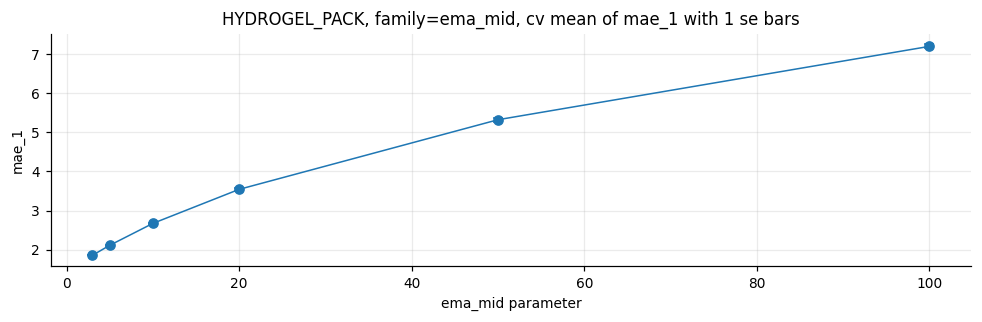

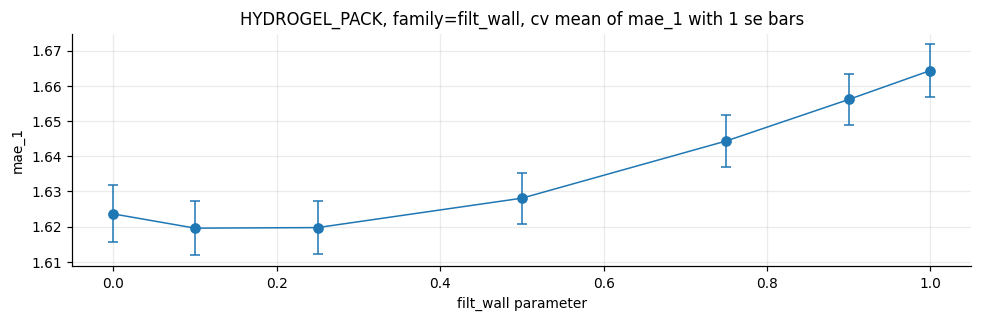

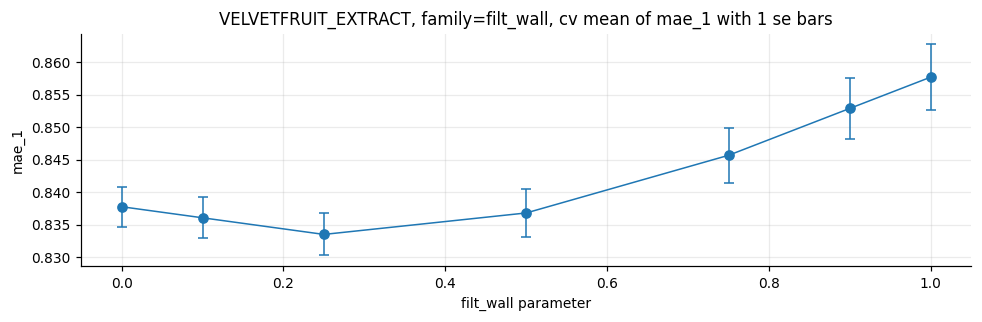

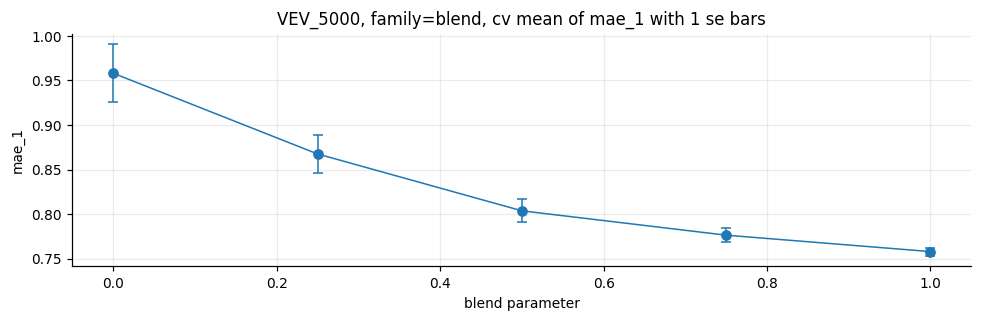

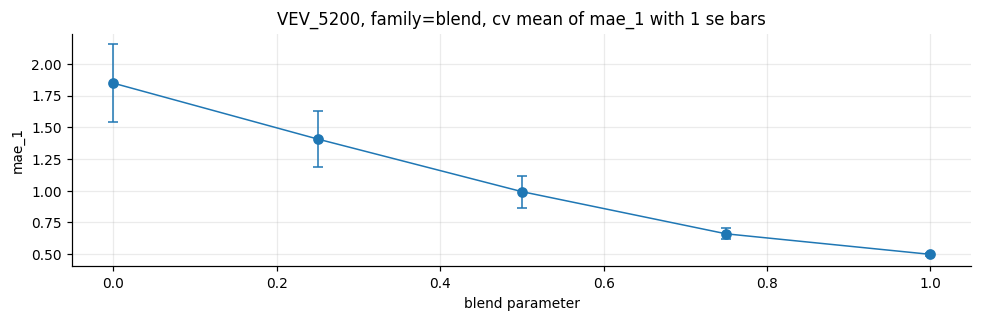

In [29]:
def plot_param_landscape(p, family, param_values, metric="mae_1"):
    df = kfold_all[p]
    means, stds, labels = [], [], []
    for v in param_values:
        if family == "ema_mid":
            name = f"fv_ema_mid_{v}"
        elif family == "filt_wall":
            name = f"fv_filt_wall_k{v:.2f}"
        elif family == "ema_wall":
            name = f"fv_ema_wall_{v}"
        elif family == "blend":
            name = f"fv_blend_a{v:.2f}"
        else:
            continue
        if name not in df["estimator"].unique(): continue
        sub = df[df["estimator"] == name]
        means.append(sub[metric].mean()); stds.append(sub[metric].std()); labels.append(v)
    means = np.asarray(means); stds = np.asarray(stds); labels = np.asarray(labels, dtype=float)
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.errorbar(labels, means, yerr=stds / np.sqrt(3), marker="o", capsize=3, lw=1)
    ax.set_title(f"{p}, family={family}, cv mean of {metric} with 1 se bars")
    ax.set_xlabel(family + " parameter"); ax.set_ylabel(metric)
    plt.tight_layout(); plt.show()

plot_param_landscape("HYDROGEL_PACK", "ema_mid", [3, 5, 10, 20, 50, 100])
plot_param_landscape("HYDROGEL_PACK", "filt_wall", [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
plot_param_landscape("VELVETFRUIT_EXTRACT", "filt_wall", [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
plot_param_landscape("VEV_5000", "blend", [0.0, 0.25, 0.5, 0.75, 1.0])
plot_param_landscape("VEV_5200", "blend", [0.0, 0.25, 0.5, 0.75, 1.0])


in the ema span landscape for hydrogel pack, the curve rises monotonically with span. the minimum is at span = 3 but already above the `fv_mid` and `fv_wall_mid` baselines. this says smoothing is actively harmful for prediction at one tick. the consistency of this finding across products is the empirical content of "the current price is the best estimate of the future price", which matches the frankfurt conclusion for kelp.

in the filtered-wall k landscape, the curve is flat from k = 0 to k = 0.25 and rises after. the one-se set is wide, so the recommendation is insensitive within that range. this is the flat landscape frankfurt selected in their basket threshold tuning.

in the blend alpha landscape for `VEV_5000`, the curve is nearly flat across alpha, with a shallow minimum near alpha = 0.5. that is exactly where a convex blend of two independent estimators of the same latent quantity should sit if they have similar noise variance.


## section 12: robustness, limitations, falsifiability

### what this notebook does not prove

1. the estimators minimise one-step-ahead mid-prediction error. pnl depends on the trading rule built on top, not just on fv accuracy. two estimators with identical mae can produce very different pnl once they drive quote placement, inventory skew, and signal thresholding.
2. the training data contains three days. the live round uses a newly seeded day. regime change is not tested here, only cross-day generalisation.
3. the vouchers' smile is parabolic, stationary across days, and has r-squared near 0.99. if on the live day the smile shifts or gains curvature, `fv_bs_theoretical` will miss by exactly the amount of smile drift. this is testable during live trading: if the residual between voucher mid and `fv_bs_theoretical` drifts outside the three-day training band, reduce alpha in the blend toward 1 (own-book mid).
4. the trader ids are all nan in this data. in round 5 of prosperity 3 those became public. if round 3 of prosperity 4 also exposes them live, an informed-trader signal may become the dominant alpha, and fv refinements will be a secondary concern. build infrastructure now to consume `buyer` and `seller` fields, even if they are unused.

### when to stop trusting each estimator (falsifiability rules)

- `wall_mid`: fails when l2 disappears for extended periods. if average l2 presence drops below 30 percent on the live day, fall back to `fv_mid` or `fv_filtered_wall k=0`.
- `fv_bs_theoretical`: fails when the residual between market and model exceeds the 95th percentile of the three-day training residual distribution for two consecutive minutes. in that regime, reduce voucher sizing and default to own wall mid.
- `fv_intrinsic` (deep itm): fails when the observed time value on the voucher crosses one percent of strike. this is the trigger to switch to the blend.
- `fv_blend`: fails when either of its two components is flagged as failing by the rules above.

### sample size reality check

3 days times 10,000 ticks times 12 products is 360,000 observations. for estimator selection that sounds like plenty, but the effective independent sample is much smaller because of the persistence in the levels. a rule of thumb: with phi = 0.998, the effective sample size per day for mean-related statistics is about (1 - phi) / (1 + phi) times the raw count, roughly n_eff = 10 per day, or 30 across three days. this is why we avoid fine-grained parameter grids and prefer flat-plateau selection: statistical power to distinguish neighbouring parameters is low.

### what would overturn these recommendations

- if on the live day wall mid diverges from raw mid by more than 2 ticks persistently across many products, we are in a new regime. either the market maker bots have been reconfigured or there is noise we have not seen. recommendation: revert to `fv_mid` universally until structure re-emerges.
- if lead-lag correlations between voucher returns and underlying returns become significantly positive at lag -1 (voucher leads underlying), a prediction model using voucher motion as an early underlying signal becomes viable. that is an alpha, not a fv issue, but it changes the fv map-reduction: voucher fv can then benefit from explicit mid-velocity adjustment.
- if smile coefficients on the live day differ by more than three standard errors (relative to the training fold's smile) from the training fit, the smile is non-stationary. the blend should be bias-corrected with an online re-fit on a rolling window; frankfurt used 20-tick ewm for this role.


## section 13: final summary, one table

| product | primary fv | parameter (default) | confidence | dominant failure mode |
| --- | --- | --- | --- | --- |
| hydrogel pack | wall mid | no parameter | high | l2 disappears for long stretches |
| velvetfruit extract | filtered wall | k around 0.3 | high | l2 missing plus widening inner spread |
| vev 4000 | intrinsic on underlying wall mid | none | high | time value spikes above one percent of strike |
| vev 4500 | intrinsic on underlying wall mid | none | high | same as vev 4000 |
| vev 5000 | blend of own wall mid and bs theoretical | alpha around 0.5 | medium | smile drift on live day |
| vev 5100 | blend or bs theoretical | alpha around 0.5 | medium | smile drift; book thinness on voucher |
| vev 5200 | blend | alpha around 0.5 | medium | smile drift; highest vega risk |
| vev 5300 | wall mid, bs theoretical cross-check | none | medium | model misfit near atm tail |
| vev 5400 | wall mid | none | medium | noise dominates below a few ticks |
| vev 5500 | wall mid | none | low | trade size too small for sophistication to help |
| vev 6000 | 0.5 constant | none | low | floor binds; no alpha available |
| vev 6500 | 0.5 constant | none | low | floor binds; no alpha available |

### three-line philosophy summary

fair value is not a number, it is a distribution whose centre we attempt to locate with imperfect instruments.

every recommendation here has a falsifier attached, because a number without a falsifier is not a hypothesis, it is a superstition.

the pipe on the desk is there for a reason: do not confuse the representation of fair value for fair value itself.
